## GPA Prediction from Student Lifestyle Data
## Exploratory Data Analysis and Data Enrichment

In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [20]:
df = pd.read_csv("student_lifestyle_dataset.csv")
df.head()
df.describe()

,Student_ID,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,GPA
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000
mean,1000.500000,7.475800,1.990100,7.501250,2.704550,4.32830,3.115960
std,577.494589,1.423888,1.155855,1.460949,1.688514,2.51411,0.298674
min,1.000000,5.000000,0.000000,5.000000,0.000000,0.00000,2.240000
25%,500.750000,6.300000,1.000000,6.200000,1.200000,2.40000,2.900000
50%,1000.500000,7.400000,2.000000,7.500000,2.600000,4.10000,3.110000
75%,1500.250000,8.700000,3.000000,8.800000,4.100000,6.10000,3.330000
max,2000.000000,10.000000,4.000000,10.000000,6.000000,13.00000,4.000000


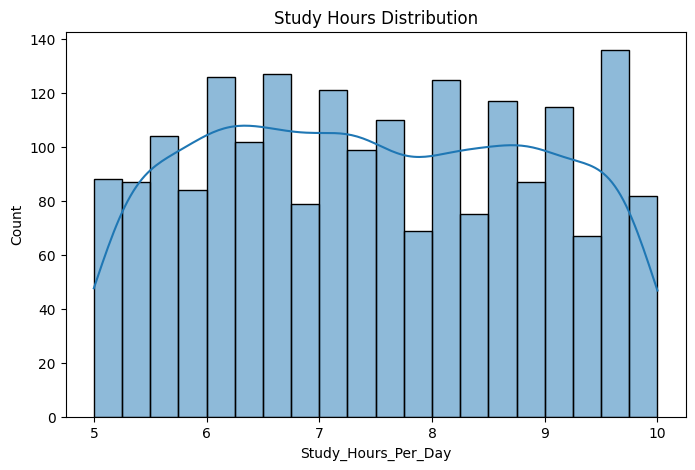

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(df["Study_Hours_Per_Day"], bins=20, kde=True)
plt.title("Study Hours Distribution")
plt.show()

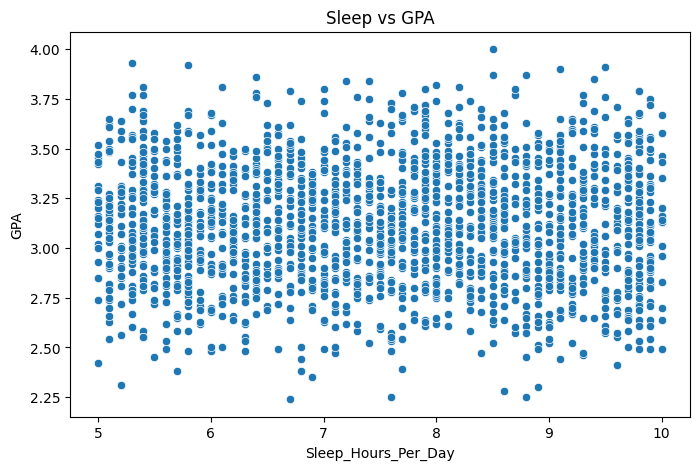

In [12]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="Sleep_Hours_Per_Day", y="GPA", data=df)
plt.title("Sleep vs GPA")
plt.show()

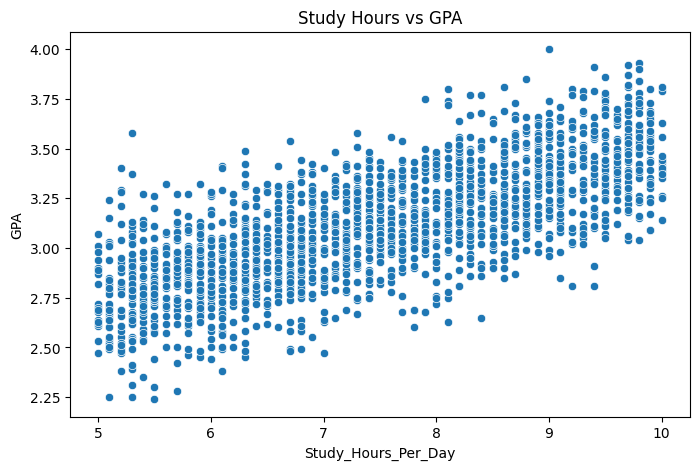

In [13]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="Study_Hours_Per_Day", y="GPA", data=df)
plt.title("Study Hours vs GPA")
plt.show()

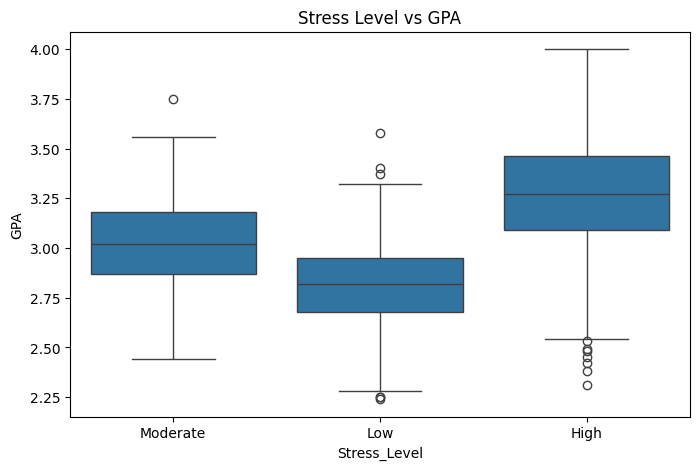

In [14]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Stress_Level", y="GPA", data=df)
plt.title("Stress Level vs GPA")
plt.show()

In [17]:
stress_map = {
    "Low": 1,
    "Moderate": 2,
    "High": 3
}

df["Stress_Level_Numeric"] = df["Stress_Level"].map(stress_map)

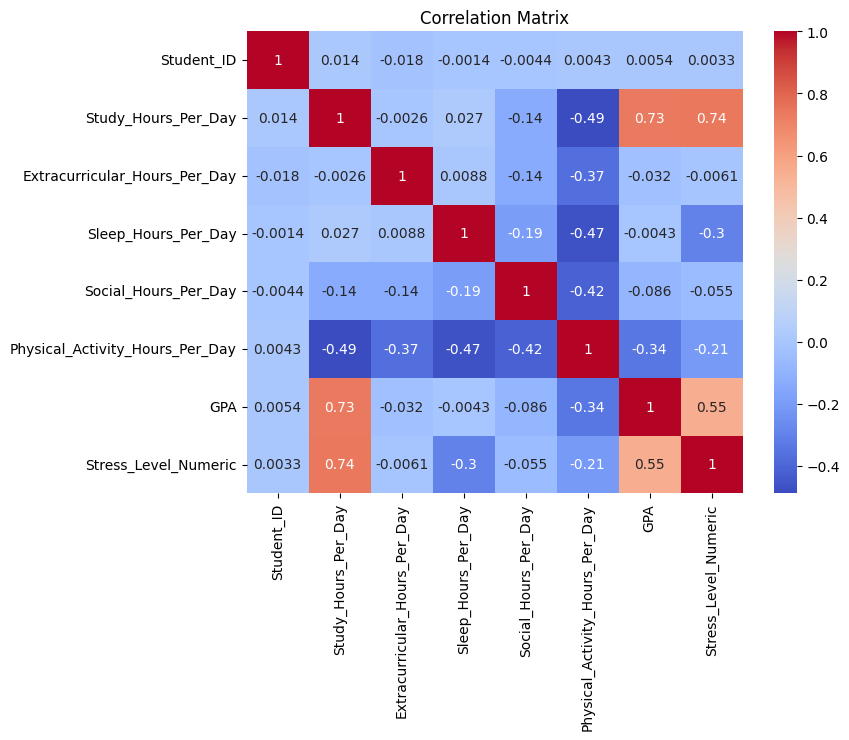

In [18]:
plt.figure(figsize=(8,6))

numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Matrix")
plt.show()

*  GPA shows positive correlation with study hours.
*  Sleep has a mild positive relationship with GPA.
*  Stress level tends to negatively affect GPA.





In [16]:
def student_profile(row):
    if row["Study_Hours_Per_Day"] > 6 and row["Sleep_Hours_Per_Day"] > 7:
        return "High"
    elif row["Study_Hours_Per_Day"] < 3:
        return "Low"
    else:
        return "Medium"

df["Student_Category"] = df.apply(student_profile, axis=1)

df.head()

,Student_ID,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,GPA,Stress_Level,Student_Category
0,1,6.9,3.8,8.7,2.8,1.8,2.99,Moderate,High
1,2,5.3,3.5,8.0,4.2,3.0,2.75,Low,Medium
2,3,5.1,3.9,9.2,1.2,4.6,2.67,Low,Medium
3,4,6.5,2.1,7.2,1.7,6.5,2.88,Moderate,High
4,5,8.1,0.6,6.5,2.2,6.6,3.51,High,Medium


In [19]:
ext = pd.read_csv("https://raw.githubusercontent.com/ageron/handson-ml/master/datasets/lifesat/oecd_bli_2015.csv")

# sadece life satisfaction
ext = ext[ext["Indicator"] == "Life satisfaction"]

# gerekli sütunlar
ext = ext[["Country", "Value"]]

ext = ext.dropna()

ext.head()

,Country,Value
2669,Australia,7.3
2670,Austria,6.9
2671,Belgium,6.9
2672,Canada,7.3
2673,Czech Republic,6.5


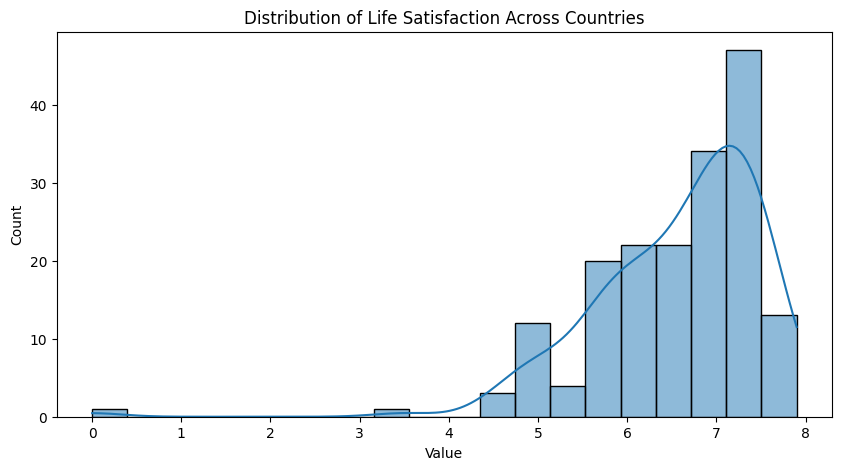

In [21]:
plt.figure(figsize=(10,5))
sns.histplot(ext["Value"], bins=20, kde=True)
plt.title("Distribution of Life Satisfaction Across Countries")
plt.show()

In [22]:
print("Mean:", ext["Value"].mean())
print("Min:", ext["Value"].min())
print("Max:", ext["Value"].max())

Mean: 6.5536312849162
Min: 0.0
Max: 7.9


Countries show a range of life satisfaction values.                         This reflects differences in overall well-being across populations.

In [23]:
def categorize(x):
    if x < 5:
        return "Low"
    elif x < 7:
        return "Medium"
    else:
        return "High"

ext["Wellbeing_Level"] = ext["Value"].apply(categorize)

ext.head()

,Country,Value,Wellbeing_Level
2669,Australia,7.3,High
2670,Austria,6.9,Medium
2671,Belgium,6.9,Medium
2672,Canada,7.3,High
2673,Czech Republic,6.5,Medium


In [24]:
mapping = {"Low": 1, "Medium": 2, "High": 3}

ext["Wellbeing_Index"] = ext["Wellbeing_Level"].map(mapping)

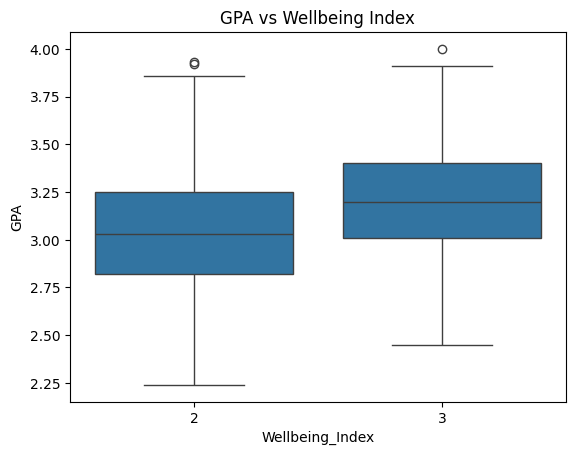

In [28]:
sns.boxplot(x="Wellbeing_Index", y="GPA", data=df)
plt.title("GPA vs Wellbeing Index")
plt.show()

In [25]:
def student_profile(row):
    if row["Study_Hours_Per_Day"] > 6 and row["Sleep_Hours_Per_Day"] > 7:
        return "High"
    elif row["Study_Hours_Per_Day"] < 3:
        return "Low"
    else:
        return "Medium"

df["Student_Category"] = df.apply(student_profile, axis=1)

In [27]:
mapping = {"Low": 1, "Medium": 2, "High": 3}

df["Wellbeing_Index"] = df["Student_Category"].map(mapping)
df.head()

,Student_ID,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,GPA,Stress_Level,Student_Category,Wellbeing_Index
0,1,6.9,3.8,8.7,2.8,1.8,2.99,Moderate,High,3
1,2,5.3,3.5,8.0,4.2,3.0,2.75,Low,Medium,2
2,3,5.1,3.9,9.2,1.2,4.6,2.67,Low,Medium,2
3,4,6.5,2.1,7.2,1.7,6.5,2.88,Moderate,High,3
4,5,8.1,0.6,6.5,2.2,6.6,3.51,High,Medium,2


- External dataset was analyzed to understand global well-being trends.
- A well-being index was derived from these trends.
- This index was integrated into the student dataset using a proxy mapping approach.
- External data provides contextual information about well-being differences across populations.

# Hypothesis Testing

In [29]:
from scipy.stats import pearsonr

In [30]:
# H0: Sleep does not affect GPA
# H1: Sleep affects GPA

corr, p = pearsonr(df["Sleep_Hours_Per_Day"], df["GPA"])

print("Correlation:", corr)
print("P-value:", p)

Correlation: -0.0042784409489437705
P-value: 0.8483540570887701


- If p < 0.05, the relationship is statistically significant.
- A positive correlation means more sleep is associated with higher GPA.

In [31]:
# H0: Study hours do not affect GPA
# H1: Study hours affect GPA

corr, p = pearsonr(df["Study_Hours_Per_Day"], df["GPA"])

print("Correlation:", corr)
print("P-value:", p)

Correlation: 0.7344679806560517
P-value: 0.0


A positive correlation suggests that studying more leads to higher GPA.

In [32]:
stress_map = {
    "Low": 1,
    "Moderate": 2,
    "High": 3
}

df["Stress_Num"] = df["Stress_Level"].map(stress_map)

In [33]:
# H0: Stress does not affect GPA
# H1: Stress affects GPA

corr, p = pearsonr(df["Stress_Num"], df["GPA"])

print("Correlation:", corr)
print("P-value:", p)

Correlation: 0.5503947345170652
P-value: 8.726002021727471e-159


A negative correlation suggests that higher stress reduces GPA.

Overall, the results support the hypothesis that lifestyle variables influence GPA.

### Conclusion

- The analysis shows that lifestyle factors such as sleep, study hours, and stress
have meaningful relationships with GPA.

- The inclusion of external well-being data helped enrich the dataset and provided additional context for understanding student performance.